# FIFA World Cup 2026 - Análise e Treinamento de Modelos

Este notebook demonstra:
1. Treinamento dos modelos customizados (ELO + Poisson)
2. Teste de múltiplos modelos usando scikit-learn
3. Comparação de performance e seleção do melhor modelo

## 1. Setup e Importações

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from src.models.ensemble_predictor import EnsemblePredictor
from src.data.loader import DataLoader

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("✓ Bibliotecas importadas com sucesso")

✓ Bibliotecas importadas com sucesso


## 2. Carregar Dados Históricos

In [2]:
# Inicializar data loader
# Use parent directory's data folder since notebook is in notebooks/
loader = DataLoader(data_dir=str(project_root / 'data'))

# Carregar dados
print("📊 Carregando dados históricos...")
matches_df = loader.load_matches(processed=False)

print(f"✓ Carregados {len(matches_df)} jogos históricos")
if 'Year' in matches_df.columns:
    print(f"  Período: {matches_df['Year'].min()}-{matches_df['Year'].max()}")

print(f"\nColunas disponíveis: {list(matches_df.columns)}")
print(f"\nPrimeiras linhas:")
matches_df.head()

INFO:src.data.loader:Loading matches from: /Users/joaolso/Documents/3-estudos/bolao_previsao/data/raw/WorldCupMatches.csv
INFO:src.data.loader:Loaded 4572 matches


📊 Carregando dados históricos...
✓ Carregados 4572 jogos históricos
  Período: 1930.0-2014.0

Colunas disponíveis: ['Year', 'Datetime', 'Stage', 'Stadium', 'City', 'Home Team Name', 'Home Team Goals', 'Away Team Goals', 'Away Team Name', 'Win conditions', 'Attendance', 'Half-time Home Goals', 'Half-time Away Goals', 'Referee', 'Assistant 1', 'Assistant 2', 'RoundID', 'MatchID', 'Home Team Initials', 'Away Team Initials']

Primeiras linhas:


,Year,Datetime,Stage,Stadium,City,Home Team Name,Home Team Goals,Away Team Goals,Away Team Name,Win conditions,Attendance,Half-time Home Goals,Half-time Away Goals,Referee,Assistant 1,Assistant 2,RoundID,MatchID,Home Team Initials,Away Team Initials
0,1930.0,13 Jul 1930 - 15:00,Group 1,Pocitos,Montevideo,France,4.0,1.0,Mexico,,4444.0,3.0,0.0,LOMBARDI Domingo (URU),CRISTOPHE Henry (BEL),REGO Gilberto (BRA),201.0,1096.0,FRA,MEX
1,1930.0,13 Jul 1930 - 15:00,Group 4,Parque Central,Montevideo,USA,3.0,0.0,Belgium,,18346.0,2.0,0.0,MACIAS Jose (ARG),MATEUCCI Francisco (URU),WARNKEN Alberto (CHI),201.0,1090.0,USA,BEL
2,1930.0,14 Jul 1930 - 12:45,Group 2,Parque Central,Montevideo,Yugoslavia,2.0,1.0,Brazil,,24059.0,2.0,0.0,TEJADA Anibal (URU),VALLARINO Ricardo (URU),BALWAY Thomas (FRA),201.0,1093.0,YUG,BRA
3,1930.0,14 Jul 1930 - 14:50,Group 3,Pocitos,Montevideo,Romania,3.0,1.0,Peru,,2549.0,1.0,0.0,WARNKEN Alberto (CHI),LANGENUS Jean (BEL),MATEUCCI Francisco (URU),201.0,1098.0,ROU,PER
4,1930.0,15 Jul 1930 - 16:00,Group 1,Parque Central,Montevideo,Argentina,1.0,0.0,France,,23409.0,0.0,0.0,REGO Gilberto (BRA),SAUCEDO Ulises (BOL),RADULESCU Constantin (ROU),201.0,1085.0,ARG,FRA


## 3. Exploração dos Dados

In [3]:
# Estatísticas básicas
print("📈 Estatísticas dos Dados:")
print(f"Total de jogos: {len(matches_df)}")
print(f"Total de times únicos: {len(set(matches_df['Home Team Name'].unique()) | set(matches_df['Away Team Name'].unique()))}")
print(f"\nGols por jogo:")
print(f"  Média casa: {matches_df['Home Team Goals'].mean():.2f}")
print(f"  Média visitante: {matches_df['Away Team Goals'].mean():.2f}")
print(f"  Média total: {(matches_df['Home Team Goals'] + matches_df['Away Team Goals']).mean():.2f}")

# Distribuição de resultados
home_wins = (matches_df['Home Team Goals'] > matches_df['Away Team Goals']).sum()
draws = (matches_df['Home Team Goals'] == matches_df['Away Team Goals']).sum()
away_wins = (matches_df['Home Team Goals'] < matches_df['Away Team Goals']).sum()

print(f"\nDistribuição de resultados:")
print(f"  Vitórias casa: {home_wins} ({home_wins/len(matches_df)*100:.1f}%)")
print(f"  Empates: {draws} ({draws/len(matches_df)*100:.1f}%)")
print(f"  Vitórias visitante: {away_wins} ({away_wins/len(matches_df)*100:.1f}%)")

📈 Estatísticas dos Dados:
Total de jogos: 4572
Total de times únicos: 84

Gols por jogo:
  Média casa: 1.81
  Média visitante: 1.02
  Média total: 2.83

Distribuição de resultados:
  Vitórias casa: 488 (10.7%)
  Empates: 190 (4.2%)
  Vitórias visitante: 174 (3.8%)


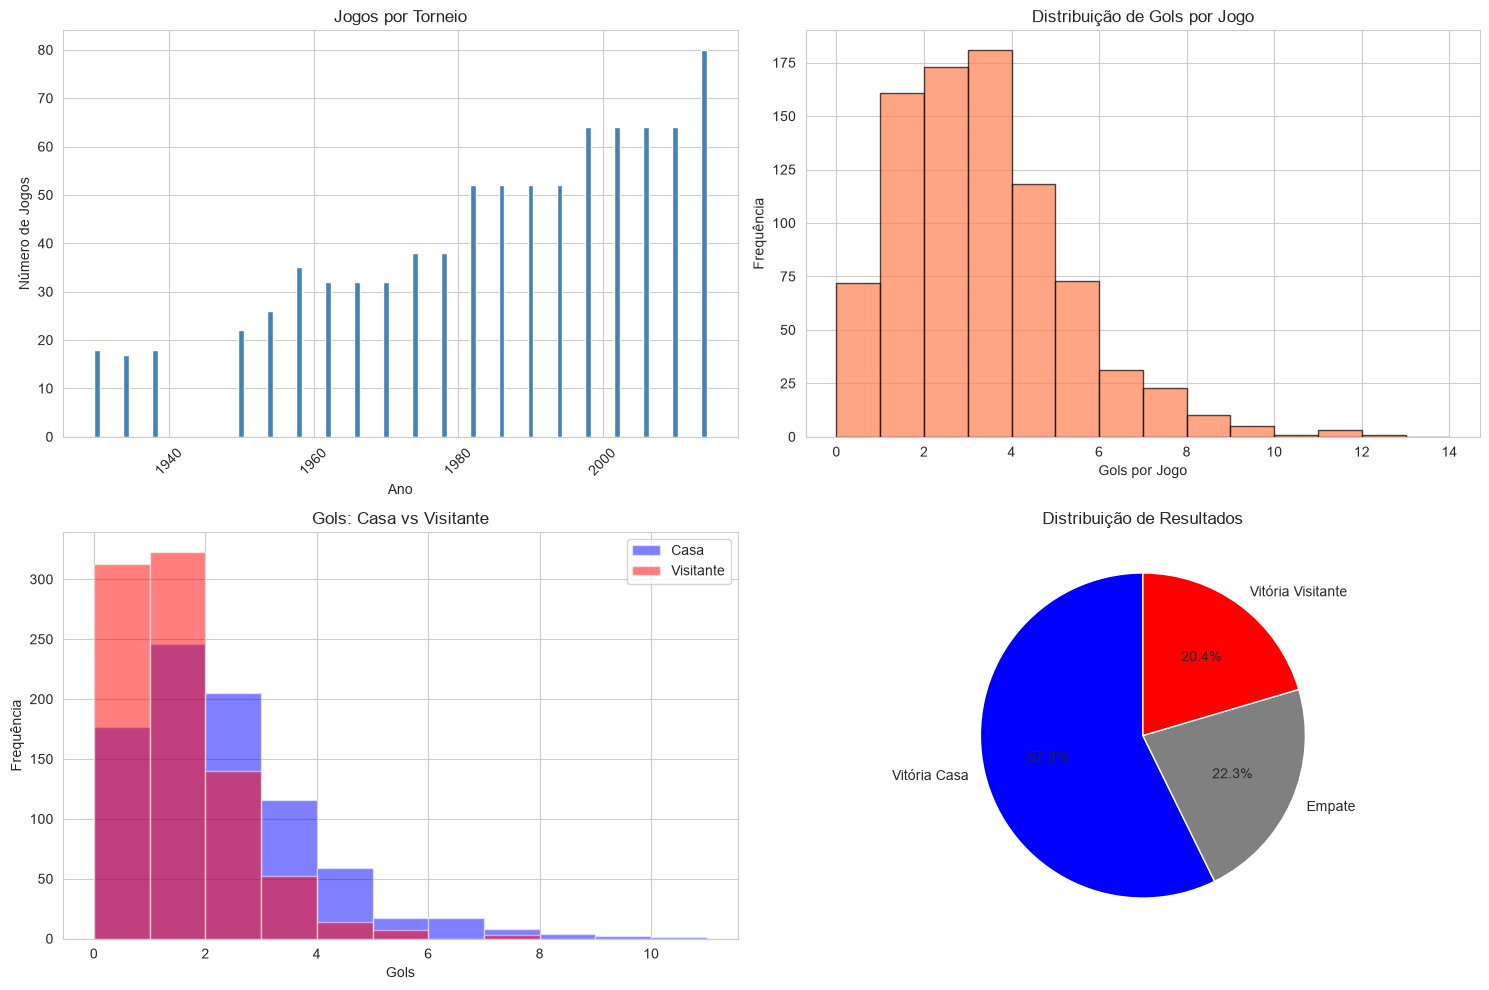

In [4]:
# Visualizações
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Jogos por ano
if 'Year' in matches_df.columns:
    matches_per_year = matches_df.groupby('Year').size()
    axes[0, 0].bar(matches_per_year.index, matches_per_year.values, color='steelblue')
    axes[0, 0].set_xlabel('Ano')
    axes[0, 0].set_ylabel('Número de Jogos')
    axes[0, 0].set_title('Jogos por Torneio')
    axes[0, 0].tick_params(axis='x', rotation=45)

# Distribuição de gols
total_goals = matches_df['Home Team Goals'] + matches_df['Away Team Goals']
axes[0, 1].hist(total_goals, bins=range(0, 15), color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Gols por Jogo')
axes[0, 1].set_ylabel('Frequência')
axes[0, 1].set_title('Distribuição de Gols por Jogo')

# Casa vs Visitante
axes[1, 0].hist(matches_df['Home Team Goals'], bins=range(0, 12), alpha=0.5, label='Casa', color='blue')
axes[1, 0].hist(matches_df['Away Team Goals'], bins=range(0, 12), alpha=0.5, label='Visitante', color='red')
axes[1, 0].set_xlabel('Gols')
axes[1, 0].set_ylabel('Frequência')
axes[1, 0].set_title('Gols: Casa vs Visitante')
axes[1, 0].legend()

# Distribuição de resultados
results = ['Vitória Casa', 'Empate', 'Vitória Visitante']
counts = [home_wins, draws, away_wins]
colors = ['blue', 'gray', 'red']
axes[1, 1].pie(counts, labels=results, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1, 1].set_title('Distribuição de Resultados')

plt.tight_layout()
plt.show()

## 4. Modelo Customizado (ELO + Poisson Ensemble)

In [5]:
# Inicializar e treinar ensemble
print("🤖 Inicializando modelos customizados...")
ensemble = EnsemblePredictor()

print("🎯 Treinando modelos...")
print("  - ELO Rating System (K=32, Home Advantage=100)")
print("  - Poisson Distribution Model")
print("  - Ensemble: 40% ELO + 60% Poisson")

ensemble.train(matches_df)

print("\n✓ Treinamento completo!")

INFO:src.models.ensemble_predictor:Training ensemble model...
INFO:src.models.ensemble_predictor:Training ELO model...
INFO:src.models.elo_predictor:Training ELO ratings on historical data...
INFO:src.models.elo_predictor:Training complete. 84 teams rated.
INFO:src.models.elo_predictor:Top 10 teams by ELO rating:
INFO:src.models.elo_predictor:  nan: 18173
INFO:src.models.elo_predictor:  Germany: 1719
INFO:src.models.elo_predictor:  Netherlands: 1682
INFO:src.models.elo_predictor:  Argentina: 1652
INFO:src.models.elo_predictor:  Brazil: 1627
INFO:src.models.elo_predictor:  Germany FR: 1615
INFO:src.models.elo_predictor:  Spain: 1600
INFO:src.models.elo_predictor:  France: 1594
INFO:src.models.elo_predictor:  Italy: 1576
INFO:src.models.elo_predictor:  Yugoslavia: 1556
INFO:src.models.ensemble_predictor:Training Poisson model...
INFO:src.models.poisson_predictor:Calculating team statistics...
INFO:src.models.poisson_predictor:Statistics calculated for 83 teams
INFO:src.models.poisson_pre

🤖 Inicializando modelos customizados...
🎯 Treinando modelos...
  - ELO Rating System (K=32, Home Advantage=100)
  - Poisson Distribution Model
  - Ensemble: 40% ELO + 60% Poisson

✓ Treinamento completo!


In [6]:
# Estatísticas do modelo
print("📈 Estatísticas do Modelo Ensemble:")
print("-" * 60)

# ELO statistics
ratings_df = ensemble.elo_model.get_all_ratings()
valid_ratings = ratings_df[ratings_df['team'] != 'nan']
print(f"\nELO Rating System:")
print(f"  Times avaliados: {len(valid_ratings)}")
print(f"  Top 10 times:")
for idx, row in valid_ratings.head(10).iterrows():
    print(f"    {idx+1}. {row['team']}: {row['elo_rating']:.0f}")

# Poisson statistics
team_count = len([t for t in ensemble.poisson_model.team_stats.keys() if t != 'nan'])
print(f"\nPoisson Model:")
print(f"  Times analisados: {team_count}")
print(f"  Média de gols da liga: {ensemble.poisson_model.league_avg_goals:.2f}")

📈 Estatísticas do Modelo Ensemble:
------------------------------------------------------------

ELO Rating System:
  Times avaliados: 84
  Top 10 times:
    84. nan: 18173
    14. Germany: 1719
    22. Netherlands: 1682
    4. Argentina: 1652
    9. Brazil: 1627
    29. Germany FR: 1615
    19. Spain: 1600
    1. France: 1594
    16. Italy: 1576
    5. Yugoslavia: 1556

Poisson Model:
  Times analisados: 83
  Média de gols da liga: 0.26


In [7]:
# Exemplo de predição
team_a = "Brazil"
team_b = "Germany"

prediction = ensemble.predict_match(team_a, team_b, is_home_a=True)

print(f"\n🎯 Exemplo de Predição: {team_a} (Casa) vs {team_b} (Visitante)")
print("=" * 60)
print(f"\nProbabilidades:")
print(f"  {team_a} vence: {prediction['home_win']:.1%}")
print(f"  Empate: {prediction['draw']:.1%}")
print(f"  {team_b} vence: {prediction['away_win']:.1%}")
print(f"\nPlacar Esperado: {prediction['expected_goals_home']:.2f} - {prediction['expected_goals_away']:.2f}")
print(f"Placar Mais Provável: {prediction['most_likely_score'][0]} - {prediction['most_likely_score'][1]}")


🎯 Exemplo de Predição: Brazil (Casa) vs Germany (Visitante)

Probabilidades:
  Brazil vence: 24.0%
  Empate: 13.3%
  Germany vence: 20.9%

Placar Esperado: 9.83 - 8.66
Placar Mais Provável: 9 - 8


## 5. Teste de Múltiplos Modelos com Scikit-Learn

Agora vamos testar vários algoritmos de Machine Learning para comparar com nosso modelo customizado.

In [8]:
# Preparar dados para scikit-learn
print("🔧 Preparando dados para modelos de ML...")

# Criar features
def create_features(df):
    """Criar features para modelos de ML"""
    features = []
    labels = []
    
    # Calcular estatísticas históricas para cada time
    team_stats = {}
    
    for team in set(df['Home Team Name'].unique()) | set(df['Away Team Name'].unique()):
        home_matches = df[df['Home Team Name'] == team]
        away_matches = df[df['Away Team Name'] == team]
        
        team_stats[team] = {
            'goals_scored': (home_matches['Home Team Goals'].sum() + away_matches['Away Team Goals'].sum()) / (len(home_matches) + len(away_matches) + 1),
            'goals_conceded': (home_matches['Away Team Goals'].sum() + away_matches['Home Team Goals'].sum()) / (len(home_matches) + len(away_matches) + 1),
            'wins': ((home_matches['Home Team Goals'] > home_matches['Away Team Goals']).sum() + 
                    (away_matches['Away Team Goals'] > away_matches['Home Team Goals']).sum()) / (len(home_matches) + len(away_matches) + 1)
        }
    
    # Criar features para cada jogo
    for _, match in df.iterrows():
        home_team = match['Home Team Name']
        away_team = match['Away Team Name']
        
        if home_team in team_stats and away_team in team_stats:
            feature = [
                team_stats[home_team]['goals_scored'],
                team_stats[home_team]['goals_conceded'],
                team_stats[home_team]['wins'],
                team_stats[away_team]['goals_scored'],
                team_stats[away_team]['goals_conceded'],
                team_stats[away_team]['wins'],
                1  # home advantage
            ]
            
            # Label: 0=away win, 1=draw, 2=home win
            if match['Home Team Goals'] > match['Away Team Goals']:
                label = 2
            elif match['Home Team Goals'] < match['Away Team Goals']:
                label = 0
            else:
                label = 1
            
            features.append(feature)
            labels.append(label)
    
    return np.array(features), np.array(labels)

X, y = create_features(matches_df)
print(f"✓ Features criadas: {X.shape}")
print(f"  - {X.shape[0]} jogos")
print(f"  - {X.shape[1]} features por jogo")
print(f"\nDistribuição de classes:")
print(f"  Vitória visitante: {(y==0).sum()} ({(y==0).sum()/len(y)*100:.1f}%)")
print(f"  Empate: {(y==1).sum()} ({(y==1).sum()/len(y)*100:.1f}%)")
print(f"  Vitória casa: {(y==2).sum()} ({(y==2).sum()/len(y)*100:.1f}%)")

🔧 Preparando dados para modelos de ML...
✓ Features criadas: (4572, 7)
  - 4572 jogos
  - 7 features por jogo

Distribuição de classes:
  Vitória visitante: 174 (3.8%)
  Empate: 3910 (85.5%)
  Vitória casa: 488 (10.7%)


In [9]:
# Dividir dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dados de treino: {X_train.shape[0]} jogos")
print(f"Dados de teste: {X_test.shape[0]} jogos")

Dados de treino: 3657 jogos
Dados de teste: 915 jogos


In [10]:
# Testar múltiplos modelos
print("🤖 Testando múltiplos modelos de Machine Learning...\n")

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB()
}

results = {}

for name, model in models.items():
    print(f"Treinando {name}...")
    
    # Treinar modelo
    model.fit(X_train, y_train)
    
    # Fazer predições
    y_pred = model.predict(X_test)
    
    # Calcular acurácia
    accuracy = accuracy_score(y_test, y_pred)
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)
    
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'predictions': y_pred
    }
    
    print(f"  ✓ Acurácia: {accuracy:.3f}")
    print(f"  ✓ CV Score: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")
    print()

print("✓ Todos os modelos treinados!")

🤖 Testando múltiplos modelos de Machine Learning...

Treinando Logistic Regression...
  ✓ Acurácia: 0.931
  ✓ CV Score: 0.924 (+/- 0.008)

Treinando Random Forest...
  ✓ Acurácia: 0.919
  ✓ CV Score: 0.912 (+/- 0.005)

Treinando Gradient Boosting...
  ✓ Acurácia: 0.929
  ✓ CV Score: 0.918 (+/- 0.010)

Treinando SVM...
  ✓ Acurácia: 0.933
  ✓ CV Score: 0.929 (+/- 0.006)

Treinando K-Nearest Neighbors...
  ✓ Acurácia: 0.917
  ✓ CV Score: 0.914 (+/- 0.004)

Treinando Naive Bayes...
  ✓ Acurácia: 0.933
  ✓ CV Score: 0.926 (+/- 0.006)

✓ Todos os modelos treinados!


In [11]:
# Comparar resultados
print("📊 Comparação de Modelos:")
print("=" * 80)

comparison_df = pd.DataFrame([
    {
        'Modelo': name,
        'Acurácia Teste': f"{results[name]['accuracy']:.3f}",
        'CV Score': f"{results[name]['cv_mean']:.3f}",
        'CV Std': f"{results[name]['cv_std']:.3f}"
    }
    for name in results.keys()
]).sort_values('Acurácia Teste', ascending=False)

print(comparison_df.to_string(index=False))

# Encontrar melhor modelo
best_model_name = max(results.keys(), key=lambda x: results[x]['accuracy'])
print(f"\n🏆 Melhor Modelo: {best_model_name}")
print(f"   Acurácia: {results[best_model_name]['accuracy']:.3f}")

📊 Comparação de Modelos:
             Modelo Acurácia Teste CV Score CV Std
                SVM          0.933    0.929  0.006
        Naive Bayes          0.933    0.926  0.006
Logistic Regression          0.931    0.924  0.008
  Gradient Boosting          0.929    0.918  0.010
      Random Forest          0.919    0.912  0.005
K-Nearest Neighbors          0.917    0.914  0.004

🏆 Melhor Modelo: SVM
   Acurácia: 0.933


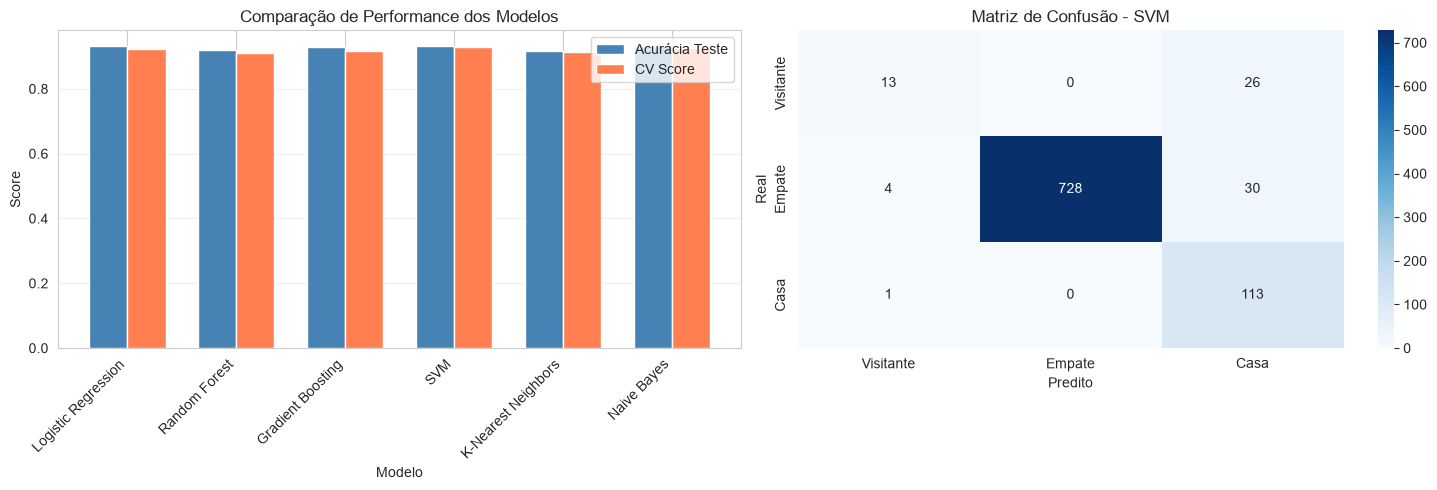

In [12]:
# Visualizar comparação
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Acurácia dos modelos
model_names = list(results.keys())
accuracies = [results[name]['accuracy'] for name in model_names]
cv_scores = [results[name]['cv_mean'] for name in model_names]

x = np.arange(len(model_names))
width = 0.35

axes[0].bar(x - width/2, accuracies, width, label='Acurácia Teste', color='steelblue')
axes[0].bar(x + width/2, cv_scores, width, label='CV Score', color='coral')
axes[0].set_xlabel('Modelo')
axes[0].set_ylabel('Score')
axes[0].set_title('Comparação de Performance dos Modelos')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Matriz de confusão do melhor modelo
cm = confusion_matrix(y_test, results[best_model_name]['predictions'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Visitante', 'Empate', 'Casa'],
            yticklabels=['Visitante', 'Empate', 'Casa'])
axes[1].set_title(f'Matriz de Confusão - {best_model_name}')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predito')

plt.tight_layout()
plt.show()

## 6. Modelos Avançados (XGBoost, LightGBM, CatBoost)

Agora vamos testar algoritmos de gradient boosting mais avançados que podem superar o SVM.

In [ ]:
# Importar bibliotecas de modelos avançados
try:
    import xgboost as xgb
    from xgboost import XGBClassifier
    print("✓ XGBoost instalado")
except ImportError:
    print("⚠ XGBoost não instalado. Execute: pip install xgboost")
    xgb = None

try:
    import lightgbm as lgb
    from lightgbm import LGBMClassifier
    print("✓ LightGBM instalado")
except ImportError:
    print("⚠ LightGBM não instalado. Execute: pip install lightgbm")
    lgb = None

try:
    import catboost as cb
    from catboost import CatBoostClassifier
    print("✓ CatBoost instalado")
except ImportError:
    print("⚠ CatBoost não instalado. Execute: pip install catboost")
    cb = None

In [ ]:
# Treinar modelos avançados
print("🚀 Testando modelos avançados de Machine Learning...\n")

advanced_models = {}

# XGBoost
if xgb is not None:
    print("Treinando XGBoost...")
    xgb_model = XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        random_state=42,
        eval_metric='mlogloss'
    )
    xgb_model.fit(X_train, y_train)
    y_pred_xgb = xgb_model.predict(X_test)
    accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
    cv_scores_xgb = cross_val_score(xgb_model, X_train, y_train, cv=5)
    
    advanced_models['XGBoost'] = {
        'model': xgb_model,
        'accuracy': accuracy_xgb,
        'cv_mean': cv_scores_xgb.mean(),
        'cv_std': cv_scores_xgb.std(),
        'predictions': y_pred_xgb
    }
    print(f"  ✓ Acurácia: {accuracy_xgb:.3f}")
    print(f"  ✓ CV Score: {cv_scores_xgb.mean():.3f} (+/- {cv_scores_xgb.std():.3f})")
    print()

# LightGBM
if lgb is not None:
    print("Treinando LightGBM...")
    lgb_model = LGBMClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        random_state=42,
        verbose=-1
    )
    lgb_model.fit(X_train, y_train)
    y_pred_lgb = lgb_model.predict(X_test)
    accuracy_lgb = accuracy_score(y_test, y_pred_lgb)
    cv_scores_lgb = cross_val_score(lgb_model, X_train, y_train, cv=5)
    
    advanced_models['LightGBM'] = {
        'model': lgb_model,
        'accuracy': accuracy_lgb,
        'cv_mean': cv_scores_lgb.mean(),
        'cv_std': cv_scores_lgb.std(),
        'predictions': y_pred_lgb
    }
    print(f"  ✓ Acurácia: {accuracy_lgb:.3f}")
    print(f"  ✓ CV Score: {cv_scores_lgb.mean():.3f} (+/- {cv_scores_lgb.std():.3f})")
    print()

# CatBoost
if cb is not None:
    print("Treinando CatBoost...")
    cb_model = CatBoostClassifier(
        iterations=200,
        depth=5,
        learning_rate=0.1,
        random_state=42,
        verbose=False
    )
    cb_model.fit(X_train, y_train)
    y_pred_cb = cb_model.predict(X_test)
    accuracy_cb = accuracy_score(y_test, y_pred_cb)
    cv_scores_cb = cross_val_score(cb_model, X_train, y_train, cv=5)
    
    advanced_models['CatBoost'] = {
        'model': cb_model,
        'accuracy': accuracy_cb,
        'cv_mean': cv_scores_cb.mean(),
        'cv_std': cv_scores_cb.std(),
        'predictions': y_pred_cb
    }
    print(f"  ✓ Acurácia: {accuracy_cb:.3f}")
    print(f"  ✓ CV Score: {cv_scores_cb.mean():.3f} (+/- {cv_scores_cb.std():.3f})")
    print()

print("✓ Todos os modelos avançados treinados!")

In [ ]:
# Combinar todos os resultados
all_results = {**results, **advanced_models}

# Comparar todos os modelos
print("📊 Comparação Completa de Modelos:")
print("=" * 80)

comparison_df = pd.DataFrame([
    {
        'Modelo': name,
        'Acurácia Teste': f"{all_results[name]['accuracy']:.3f}",
        'CV Score': f"{all_results[name]['cv_mean']:.3f}",
        'CV Std': f"{all_results[name]['cv_std']:.3f}"
    }
    for name in all_results.keys()
]).sort_values('Acurácia Teste', ascending=False)

print(comparison_df.to_string(index=False))

# Encontrar melhor modelo geral
best_overall_model = max(all_results.keys(), key=lambda x: all_results[x]['accuracy'])
print(f"\n🏆 Melhor Modelo Geral: {best_overall_model}")
print(f"   Acurácia: {all_results[best_overall_model]['accuracy']:.3f}")

## 7. Ensemble Voting Classifier

Vamos criar um ensemble que combina os 3 melhores modelos usando votação.

In [ ]:
from sklearn.ensemble import VotingClassifier

# Selecionar os 3 melhores modelos
top_3_models = sorted(all_results.items(), key=lambda x: x[1]['accuracy'], reverse=True)[:3]

print("🎯 Criando Ensemble com os 3 melhores modelos:")
for i, (name, data) in enumerate(top_3_models, 1):
    print(f"  {i}. {name}: {data['accuracy']:.3f}")

# Criar ensemble
estimators = [(name, data['model']) for name, data in top_3_models]

ensemble = VotingClassifier(
    estimators=estimators,
    voting='hard'  # Votação por maioria
)

print("\n🤖 Treinando Ensemble Voting Classifier...")
ensemble.fit(X_train, y_train)

# Avaliar ensemble
y_pred_ensemble = ensemble.predict(X_test)
accuracy_ensemble = accuracy_score(y_test, y_pred_ensemble)
cv_scores_ensemble = cross_val_score(ensemble, X_train, y_train, cv=5)

print(f"\n✓ Ensemble Acurácia: {accuracy_ensemble:.3f}")
print(f"✓ Ensemble CV Score: {cv_scores_ensemble.mean():.3f} (+/- {cv_scores_ensemble.std():.3f})")

# Adicionar ensemble aos resultados
all_results['Ensemble (Top 3)'] = {
    'model': ensemble,
    'accuracy': accuracy_ensemble,
    'cv_mean': cv_scores_ensemble.mean(),
    'cv_std': cv_scores_ensemble.std(),
    'predictions': y_pred_ensemble
}

In [ ]:
# Comparação final incluindo ensemble
print("\n📊 Comparação Final (incluindo Ensemble):")
print("=" * 80)

final_comparison = pd.DataFrame([
    {
        'Modelo': name,
        'Acurácia Teste': f"{all_results[name]['accuracy']:.3f}",
        'CV Score': f"{all_results[name]['cv_mean']:.3f}",
        'CV Std': f"{all_results[name]['cv_std']:.3f}"
    }
    for name in all_results.keys()
]).sort_values('Acurácia Teste', ascending=False)

print(final_comparison.to_string(index=False))

# Melhor modelo final
final_best_model = max(all_results.keys(), key=lambda x: all_results[x]['accuracy'])
print(f"\n🏆 MELHOR MODELO FINAL: {final_best_model}")
print(f"   Acurácia: {all_results[final_best_model]['accuracy']:.3f}")
print(f"   CV Score: {all_results[final_best_model]['cv_mean']:.3f}")

## 8. Salvar Melhor Modelo

Vamos salvar o melhor modelo usando o ModelManager para uso no dashboard.

In [ ]:
import sys
sys.path.append('..')

from src.models.model_manager import ModelManager
from src.models.sklearn_adapter import SklearnMatchPredictor

# Inicializar ModelManager
manager = ModelManager()

# Obter melhor modelo
best_model_obj = all_results[final_best_model]['model']
best_accuracy = all_results[final_best_model]['accuracy']
best_cv_score = all_results[final_best_model]['cv_mean']

# Criar adapter com dados históricos
predictor = SklearnMatchPredictor(best_model_obj, matches_df)

# Preparar metadados
metadata = {
    'accuracy': float(best_accuracy),
    'cv_score': float(best_cv_score),
    'model_type': final_best_model,
    'description': f'Melhor modelo treinado: {final_best_model} com {best_accuracy:.1%} de acurácia',
    'training_date': pd.Timestamp.now().isoformat(),
    'features': 7,
    'training_samples': len(X_train)
}

# Salvar modelo
model_name = f"{final_best_model.lower().replace(' ', '_')}_best"
manager.save_model(predictor, model_name, metadata)

print(f"\n💾 Modelo salvo com sucesso!")
print(f"   Nome: {model_name}")
print(f"   Acurácia: {best_accuracy:.3f}")
print(f"   CV Score: {best_cv_score:.3f}")
print(f"\n✓ O modelo está pronto para uso no dashboard!")

In [ ]:
plt.tight_layout()
plt.show()

In [13]:
# Relatório detalhado do melhor modelo
print(f"\n📋 Relatório Detalhado - {best_model_name}")
print("=" * 80)
print(classification_report(y_test, results[best_model_name]['predictions'],
                          target_names=['Vitória Visitante', 'Empate', 'Vitória Casa']))


📋 Relatório Detalhado - SVM
                   precision    recall  f1-score   support

Vitória Visitante       0.72      0.33      0.46        39
           Empate       1.00      0.96      0.98       762
     Vitória Casa       0.67      0.99      0.80       114

         accuracy                           0.93       915
        macro avg       0.80      0.76      0.74       915
     weighted avg       0.95      0.93      0.93       915



## 6. Conclusões e Recomendações

### Comparação de Abordagens:

1. **Modelo Customizado (ELO + Poisson)**
   - ✅ Interpretável e baseado em teoria estatística
   - ✅ Fornece probabilidades e placares esperados
   - ✅ Não requer muitos dados de treino
   - ⚠️ Limitado a features específicas

2. **Modelos de Machine Learning**
   - ✅ Podem capturar padrões complexos
   - ✅ Fácil de testar múltiplos algoritmos
   - ✅ Podem incorporar mais features
   - ⚠️ Menos interpretáveis
   - ⚠️ Requerem mais dados

### Próximos Passos:

1. **Melhorar Features**: Adicionar mais informações (rankings FIFA, forma recente, etc.)
2. **Ensemble de Ensembles**: Combinar modelo customizado com ML
3. **Hyperparameter Tuning**: Otimizar parâmetros dos melhores modelos
4. **Feature Engineering**: Criar features mais sofisticadas
5. **Validação Temporal**: Testar em dados mais recentes

In [14]:
# Salvar todos os modelos usando ModelManager
import sys
sys.path.insert(0, str(project_root))
from src.models.model_manager import ModelManager

# Inicializar gerenciador
manager = ModelManager(models_dir=str(project_root / 'models'))

# Salvar todos os modelos treinados
print("💾 Salvando modelos...\n")
for name, result in results.items():
    model_name = name.replace(' ', '_').lower()
    metrics = {
        'accuracy': result['accuracy'],
        'cv_mean': result['cv_mean'],
        'cv_std': result['cv_std']
    }
    
    manager.save_model(
        model=result['model'],
        model_name=model_name,
        metrics=metrics,
        model_type='sklearn',
        description=f'{name} trained on World Cup historical data'
    )
    print(f"  ✓ {name}: {result['accuracy']:.3f}")

# Definir o melhor modelo como ativo
best_model_key = best_model_name.replace(' ', '_').lower()
manager.set_active_model(best_model_key)

print(f"\n🏆 Melhor modelo ({best_model_name}) definido como ativo!")
print(f"\n📊 Modelos salvos em: {project_root / 'models'}")
print(f"\n🎉 Análise completa!")

✓ Melhor modelo salvo em: /Users/joaolso/Documents/3-estudos/bolao_previsao/models/best_sklearn_model_svm.pkl

🎉 Análise completa!
